
## Logistic Regression for Binary Classification: Part-1

## Objective
**Logistic Regression using Titanic Dataset**

Problem Statement:
Design a Logistic Regression model to predict whether a passenger survived (1) or did not survive (0) the Titanic disaster based on passenger details.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc


In [3]:
# Load the Placement dataset from the specified file path into a Pandas DataFrame
df = pd.read_csv("/content/Placement_Y_N.csv")

In [4]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [5]:
# Remove the unnecessary index column ('Unnamed: 0') from the DataFrame
df = df.drop(columns=['Unnamed: 0'])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       100 non-null    float64
 1   iq         100 non-null    float64
 2   placement  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [7]:
# Check for missing (null) values in each column of the DataFrame
df.isnull().sum()

,0
cgpa,0
iq,0
placement,0


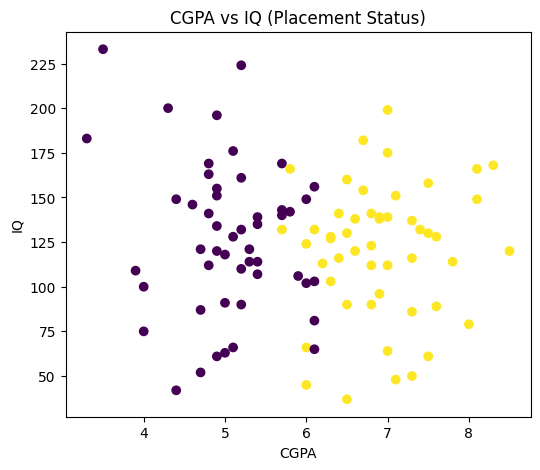

In [8]:
# Create a scatter plot of CGPA vs IQ
# Color points based on placement status (0 = Not Placed, 1 = Placed)

plt.figure(figsize=(6, 5))
plt.scatter(df['cgpa'], df['iq'], c=df['placement'])
plt.xlabel('CGPA')
plt.ylabel('IQ')
plt.title('CGPA vs IQ (Placement Status)')
plt.show()


In [9]:
# Select the independent variables (features): CGPA and IQ
X = df[['cgpa', 'iq']]

# Select the dependent variable (target): Placement status (1 = Placed, 0 = Not Placed)
y = df['placement']


In [10]:
# Split the dataset into training and testing sets
# 80% data is used for training and 20% for testing
# stratify=y ensures both classes are equally represented in train and test sets
# random_state ensures the same split every time the code is executed
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:
# Create a StandardScaler object to normalize the feature values
scaler = StandardScaler()

# Fit the scaler on training data and transform it
# This standardizes features to have mean = 0 and standard deviation = 1
X_train = scaler.fit_transform(X_train)

# Transform the test data using the same scaler
# (Important: do NOT fit again on test data)
X_test = scaler.transform(X_test)

In [12]:
# Create an object of the Logistic Regression model
model = LogisticRegression()


In [13]:
# Train (fit) the model using the training data
# The model learns the relationship between CGPA, IQ and placement outcome
model.fit(X_train, y_train)

LogisticRegression()

In [14]:
# Predict the placement outcome for the test dataset using the trained model
y_pred = model.predict(X_test)

In [15]:
# Display the accuracy of the model
# Accuracy shows the percentage of correctly classified instances
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.85


In [16]:
# Display the confusion matrix
# It shows counts of True Positives, True Negatives, False Positives, and False Negatives
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Confusion Matrix:
 [[9 1]
 [2 8]]


In [17]:
# Create a new data point for a student with CGPA = 7.8 and IQ = 120
new_student = np.array([[7.8, 120]])

# Apply the same scaling used for training data
new_student_scaled = scaler.transform(new_student)

# Predict the placement outcome for the new student
prediction = model.predict(new_student_scaled)

# Display the prediction result in a readable format
print("Prediction:", "Placed" if prediction[0] == 1 else "Not Placed")

Prediction: Placed


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [18]:
import pickle

In [19]:
pickle.dump(model,open('BCModel.pkl','wb'))

In [20]:
from flask import Flask, render_template, request
import pickle
import numpy as np

app = Flask(__name__)

# Load Trained Logistic Regression Model
model = pickle.load(open("BCModel.pkl", "rb"))


@app.route('/')
def home():
    return render_template("index.html")


@app.route('/predict', methods=['POST'])
def predict():

    # Read user inputs
    cgpa = float(request.form['cgpa'])
    iq = float(request.form['iq'])

    # Prediction
    prediction = model.predict(np.array([[cgpa, iq]]))

    # Convert numeric prediction to text
    if prediction[0] == 1:
        result = "Student is Likely to be PLACED"
    else:
        result = "Student is NOT Likely to be PLACED"

    return render_template(
        "index.html",
        prediction_text=result
    )


if __name__ == "__main__":
    app.run(debug=True)

In [24]:
print(model.classes_)

[0 1]


In [23]:
print(model.predict([
    [5, 70],
    [6, 80],
    [7, 100],
    [8, 120],
    [9, 140]
]))

[1 1 1 1 1]


In [27]:
import pickle

model_data = {
    "model": model,
    "scaler": scaler
}

pickle.dump(model_data, open("BCModel.pkl", "wb"))